In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
# 0 = All logs, 1 = Filter INFO, 2 = Filter INFO/WARNING, 3 = Filter all

In [2]:
import os
# Force TensorFlow to bypass the Autotuner and JIT compilation errors
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0' 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'

import tensorflow as tf

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU and Hardware ready for InceptionV3 training.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1774374948.056964   57511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774374948.953040   57511 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU and Hardware ready for InceptionV3 training.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Hyperparameters aligned with paper resolution
img_size = 224 
batch_size = 32
epochs = 30

# Dataset paths configured for WSL mount points
train_dir = "Image_Dataset/Combined Dataset/train"
test_dir = "Image_Dataset/Combined Dataset/test"

In [4]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=15, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    validation_split=0.1
)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(img_size, img_size),
    batch_size=batch_size, class_mode='categorical', subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(img_size, img_size),
    batch_size=batch_size, class_mode='categorical', subset='validation'
)

Found 6656 images belonging to 3 classes.
Found 739 images belonging to 3 classes.


In [5]:
def build_paper_model():
    # Load InceptionV3 with pre-trained ImageNet weights
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
    base_model.trainable = False

    # Adding custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x) 
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    # Final classification for 3 stages of AD
    predictions = Dense(3, activation='softmax')(x) 

    model = Model(inputs=base_model.input, outputs=predictions)
    
    # To avoid the Autotuner compile error
    model.compile(optimizer=Adam(learning_rate=1e-4), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'],
                  jit_compile=False)
    return model

model = build_paper_model()

E0000 00:00:1774374957.933230   57765 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.5.40, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [ ]:
print("\nStarting InceptionV3 Training...")
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)


model.save('alzheimers_inception_paper_model.h5')
print("\nTraining Complete. Model saved as 'alzheimers_inception_paper_model.h5'")


Starting InceptionV3 Training...
Epoch 1/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 44s 185ms/step - accuracy: 0.6810 - loss: 0.8590 - val_accuracy: 0.8525 - val_loss: 0.3738
Epoch 2/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 37s 177ms/step - accuracy: 0.7925 - loss: 0.5251 - val_accuracy: 0.8877 - val_loss: 0.2825
Epoch 3/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 37s 179ms/step - accuracy: 0.8239 - loss: 0.4585 - val_accuracy: 0.9242 - val_loss: 0.2006
Epoch 4/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 35s 167ms/step - accuracy: 0.8379 - loss: 0.4125 - val_accuracy: 0.9053 - val_loss: 0.2161
Epoch 5/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 48s 173ms/step - accuracy: 0.8613 - loss: 0.3449 - val_accuracy: 0.9188 - val_loss: 0.2051
Epoch 6/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.8655 - loss: 0.3354 - val_accuracy: 0.9053 - val_loss: 0.2321
Epoch 7/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 35s 170ms/step - accuracy: 0.8658 - loss: 0.3222 - val_accuracy: 0.9134 - val_loss: 0.1995
Epoch 8/30
208/208 ━━━━━━━━━━━━━━━━━━━━ 34s 165ms


Training Complete. Model saved as 'alzheimers_inception_paper_model.h5'


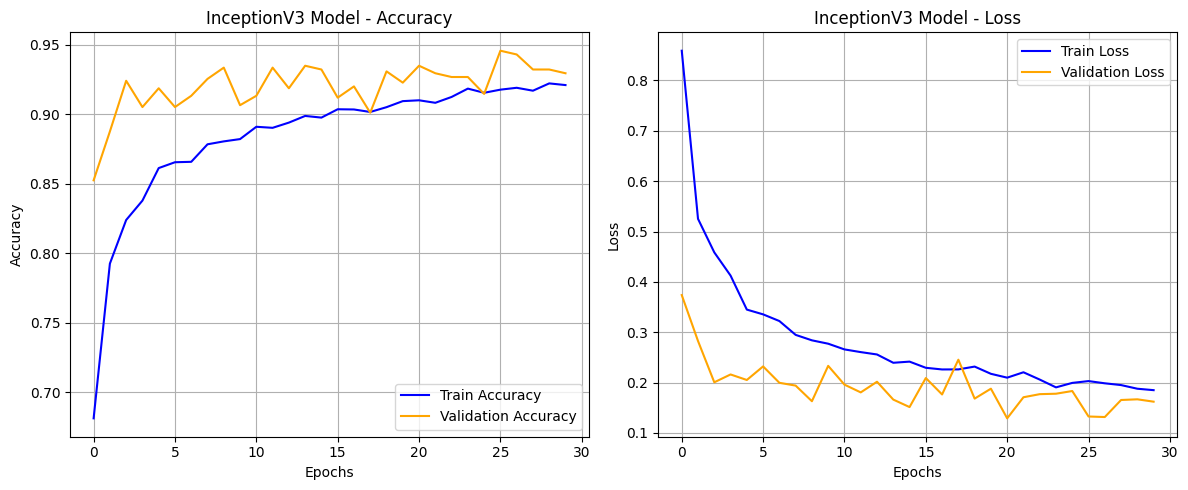

In [7]:
# Plotting the results for the Paper Version (InceptionV3)
def plot_paper_results(history):
    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    plt.title('InceptionV3 Model - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('InceptionV3 Model - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_paper_results(history)